<a href="https://colab.research.google.com/github/karlositalo/karlos_mbt_test/blob/main/questao_2_1_contagem_pessoas_yolov8_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Questão 2.1 — Contagem de pessoas com YOLOv8

Este notebook instala o pacote `ultralytics`, carrega um modelo YOLOv8 pré-treinado, executa `model.predict()`, conta somente as detecções com rótulo `person` e mostra a imagem anotada.

In [ ]:
# Instalação das bibliotecas necessárias no Google Colab
!pip -q install ultralytics

from ultralytics import YOLO
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("Bibliotecas importadas com sucesso.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 742.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Bibliotecas importadas com sucesso.


In [ ]:
# Envie a imagem person.png
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("Nenhuma imagem foi enviada.")

image_path = next(iter(uploaded))
print("Imagem selecionada:", image_path)

Saving person.png to person.png
Imagem selecionada: person.png


In [ ]:
# Leitura da imagem com OpenCV
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(
        f"Não foi possível abrir '{image_path}'. "
        "Verifique se o arquivo é uma imagem válida."
    )

# Carrega o modelo YOLOv8 nano pré-treinado.
# Na primeira execução, os pesos são baixados automaticamente.
model = YOLO("yolov8n.pt")

# Localiza o identificador da classe cujo nome é "person".
person_class_id = next(
    class_id
    for class_id, class_name in model.names.items()
    if class_name == "person"
)

# Inferência solicitada no enunciado.
# classes=[person_class_id] mantém apenas detecções de pessoas.
results = model.predict(
    source=img,
    conf=0.25,
    imgsz=640,
    classes=[person_class_id],
    verbose=False
)

result = results[0]

Pessoas detectadas: 8
Rótulos encontrados: ['person', 'person', 'person', 'person', 'person', 'person', 'person', 'person']


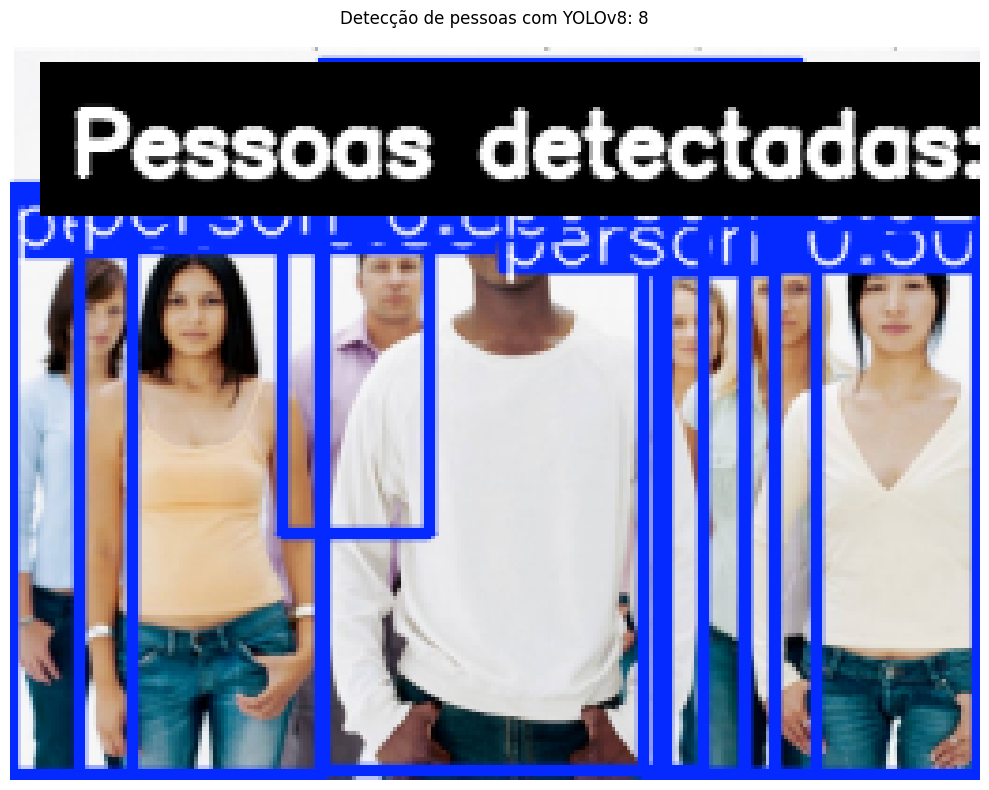

Resultado salvo em: resultado_yolov8_pessoas.png


In [ ]:
# Obtém os rótulos retornados e conta somente "person".
if result.boxes is None or len(result.boxes) == 0:
    labels = []
else:
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    labels = [result.names[class_id] for class_id in class_ids]

person_count = labels.count("person")

print(f"Pessoas detectadas: {person_count}")
print("Rótulos encontrados:", labels)

# result.plot() desenha as caixas, rótulos e níveis de confiança.
annotated = result.plot()

# Adiciona o total no topo da imagem.
cv2.rectangle(annotated, (8, 8), (310, 48), (0, 0, 0), -1)
cv2.putText(
    annotated,
    f"Pessoas detectadas: {person_count}",
    (16, 37),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.75,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

# Exibição compatível com o Google Colab.
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Detecção de pessoas com YOLOv8: {person_count}")
plt.axis("off")
plt.tight_layout()
plt.show()

# Salva a imagem anotada.
output_path = "resultado_yolov8_pessoas.png"
cv2.imwrite(output_path, annotated)

print("Resultado salvo em:", output_path)

In [ ]:
# Opcional: baixar o resultado
files.download("resultado_yolov8_pessoas.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>